Importacion de librerias y configuracion:
importantes para los graficos. tablas  y mas datos estadisticos

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

#configuracion general de los graficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [15]:
#carga de base de datos

# Definir la ruta al archivo generado por Docker
BASE_DIR = os.path.dirname(os.getcwd())
PATH_CLEANED = os.path.join(BASE_DIR, 'data', 'processed', 'london_crime_cleaned.parquet')

# Leer el archivo Parquet
df = pd.read_parquet(PATH_CLEANED)

print(f"¡Dataset cargado con éxito!")
print(f"Total de registros para analizar: {len(df):,}")
display(df.head())

¡Dataset cargado con éxito!
Total de registros para analizar: 75,312


,borough,major_category,minor_category,year,month,value,periodo
0,Barking and Dagenham,burglary,burglary in other buildings,2011,1,48,2011-01
1,Barking and Dagenham,burglary,burglary in other buildings,2011,2,48,2011-02
2,Barking and Dagenham,burglary,burglary in other buildings,2011,3,61,2011-03
3,Barking and Dagenham,burglary,burglary in other buildings,2011,4,59,2011-04
4,Barking and Dagenham,burglary,burglary in other buildings,2011,5,40,2011-05


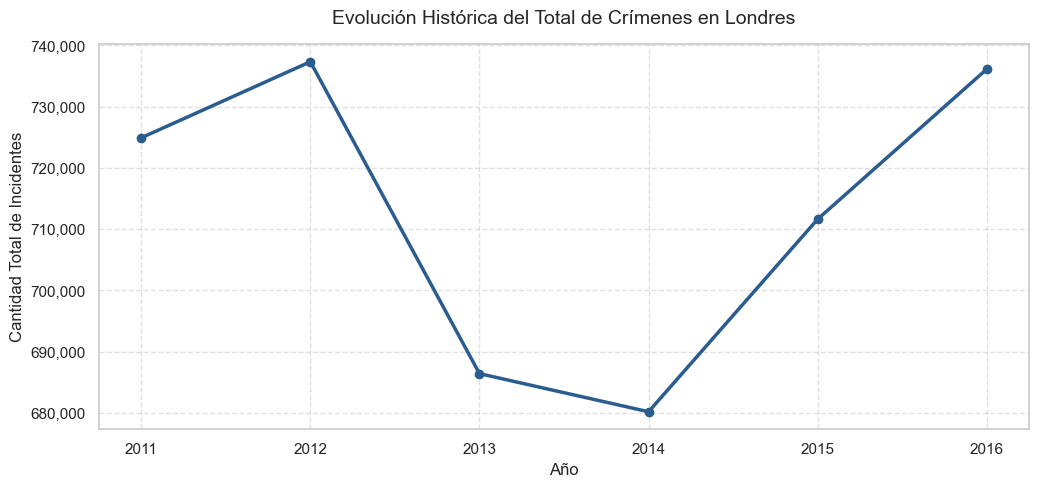

In [16]:
df_yearly = df.groupby('year')['value'].sum().reset_index()

# Forzar tipos de datos numéricos en el DataFrame resumido
df_yearly['year'] = pd.to_numeric(df_yearly['year'], errors='coerce')
df_yearly['value'] = pd.to_numeric(df_yearly['value'], errors='coerce')

# Eliminar cualquier fila con nulos remanentes en el resumen
df_yearly = df_yearly.dropna()

# Extraer los datos como arreglos numéricos puros (esto rompe el error de object/string)
años = df_yearly['year'].to_numpy().astype(int)
totales = df_yearly['value'].to_numpy().astype(float)


plt.figure(figsize=(12, 5))


plt.plot(años, totales, marker='o', color='#2b5c8f', linewidth=2.5, linestyle='-')

plt.title('Evolución Histórica del Total de Crímenes en Londres', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad Total de Incidentes', fontsize=12)
plt.xticks(años)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

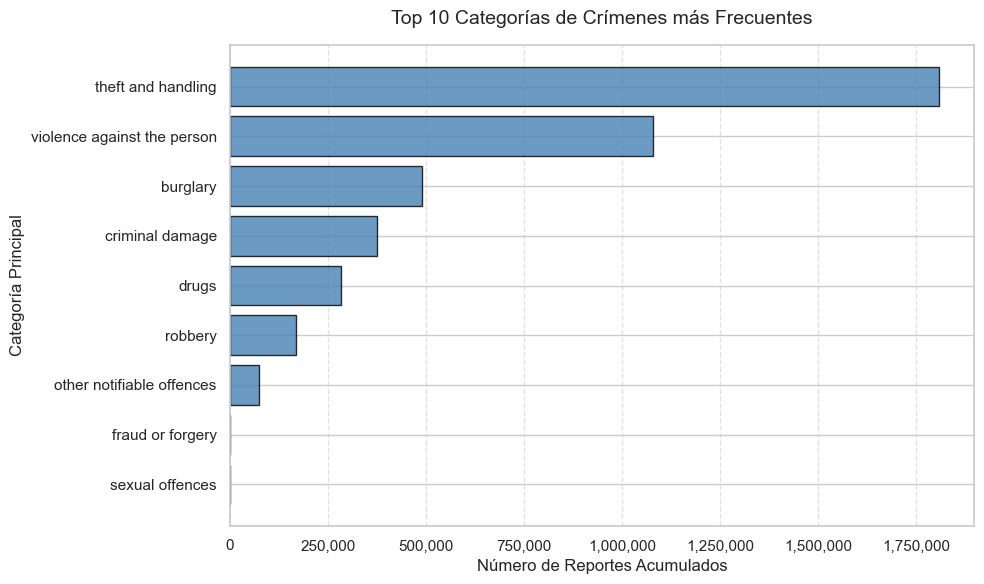

In [17]:
#Agrupar por categoría principal y sumar
df_category = df.groupby('major_category')['value'].sum().reset_index()

# Convertir el conteo a tipo numérico puro
df_category['value'] = pd.to_numeric(df_category['value'], errors='coerce')
df_category = df_category.dropna()

# Ordenar de mayor a menor y tomar el Top 10
df_category = df_category.sort_values(ascending=False, by='value').head(10)

# Extraer los datos como listas/arreglos limpios
categorias = df_category['major_category'].to_numpy().astype(str)
valores_categoria = df_category['value'].to_numpy().astype(float)

plt.figure(figsize=(10, 6))

# Graficar barras horizontales (barh)
plt.barh(categorias, valores_categoria, color='#4682B4', edgecolor='black', alpha=0.8)

plt.title('Top 10 Categorías de Crímenes más Frecuentes', fontsize=14, pad=15)
plt.xlabel('Número de Reportes Acumulados', fontsize=12)
plt.ylabel('Categoría Principal', fontsize=12)

plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

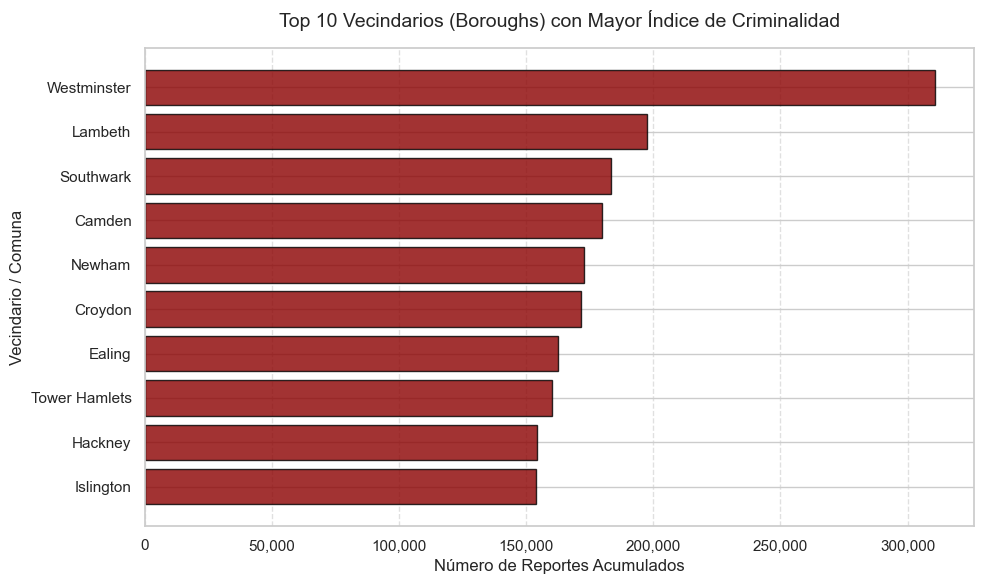

In [18]:
# 1. Agrupar por vecindario y sumar
df_borough = df.groupby('borough')['value'].sum().reset_index()

# 2. Convertir el conteo a tipo numérico puro
df_borough['value'] = pd.to_numeric(df_borough['value'], errors='coerce')
df_borough = df_borough.dropna()

# 3. Ordenar de mayor a menor y tomar el Top 10
df_borough = df_borough.sort_values(ascending=False, by='value').head(10)

# 4. Extraer los datos como listas/arreglos limpios
vecindarios = df_borough['borough'].to_numpy().astype(str)
valores_borough = df_borough['value'].to_numpy().astype(float)

# --- DISEÑO DEL GRÁFICO ---
plt.figure(figsize=(10, 6))

# Graficar barras horizontales
plt.barh(vecindarios, valores_borough, color='#8B0000', edgecolor='black', alpha=0.8)

plt.title('Top 10 Vecindarios (Boroughs) con Mayor Índice de Criminalidad', fontsize=14, pad=15)
plt.xlabel('Número de Reportes Acumulados', fontsize=12)
plt.ylabel('Vecindario / Comuna', fontsize=12)

# Invertir el eje Y para el orden correcto
plt.gca().invert_yaxis()

# Formatear el eje X con separador de miles
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()